In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as smp

# Problem 1


## a


### Symbolic

In [2]:
a, r, x, y = smp.symbols('a r x y')

f1 = r*x*(1-x)-a*y*x
f2 = a*x*y-y

In [3]:
f1

-a*x*y + r*x*(1 - x)

In [4]:
f2

a*x*y - y

In [5]:
smp.solve([f1,f2], [x,y])

[(0, 0), (1, 0), (1/a, r*(a - 1)/a**2)]

In [6]:
root1 = smp.solve([f1,f2], [x,y])[0]
root2 = smp.solve([f1,f2], [x,y])[1]
root3 = smp.solve([f1,f2], [x,y])[2]
root3

(1/a, r*(a - 1)/a**2)

In [7]:
J = smp.Matrix([[smp.diff(f1,x),smp.diff(f1,y)],
                  [smp.diff(f2,x),smp.diff(f2,y)]])

J

Matrix([
[-a*y - r*x + r*(1 - x),    -a*x],
[                   a*y, a*x - 1]])

In [8]:
smp.Matrix.eigenvals(J.subs([(x,root1[0]),
                            (y,root1[1])]))

{r: 1, -1: 1}

In [9]:
J.subs([(x,root2[0]),
                            (y,root2[1])])

Matrix([
[-r,    -a],
[ 0, a - 1]])

In [10]:
smp.Matrix.eigenvals(J.subs([(x,root2[0]),
                            (y,root2[1])]))

{a - 1: 1, -r: 1}

In [11]:
smp.Matrix.eigenvals(J.subs([(x,root3[0]),
                            (y,root3[1])]))

{-r/(2*a) - sqrt(r*(-4*a**2 + 4*a + r))/(2*a): 1,
 -r/(2*a) + sqrt(r*(-4*a**2 + 4*a + r))/(2*a): 1}

In [12]:
f1_f = smp.lambdify([x,y,a,r],f1)
f2_f = smp.lambdify([x,y,a],f2)

J_f = smp.lambdify([x,y,a,r],J)

r3_f = smp.lambdify([a,r],root3)

### Numbers

In [13]:
av = 2
rv = 1

x1 = np.linspace(-1,1.25,25)
x2 = np.linspace(-1,0.5,25)

X1, X2 = np.meshgrid(x1,x2)

In [14]:
Jz1 = np.array(J_f(root1[0],root1[1],av,rv),dtype=float)

Jz1

array([[ 1.,  0.],
       [ 0., -1.]])

In [15]:
np.linalg.eig(Jz1)

(array([ 1., -1.]),
 array([[1., 0.],
        [0., 1.]]))

In [16]:
Jz2 = np.array(J_f(root2[0],root2[1],av,rv),dtype=float)

Jz2

array([[-1., -2.],
       [ 0.,  1.]])

In [17]:
np.linalg.eig(Jz2)

(array([-1.,  1.]),
 array([[ 1.        , -0.70710678],
        [ 0.        ,  0.70710678]]))

In [18]:
Jz3 = np.array(J_f(r3_f(av,rv)[0],r3_f(av,rv)[1],av,rv),dtype=float)

Jz3

array([[-0.5, -1. ],
       [ 0.5,  0. ]])

In [19]:
np.linalg.eig(Jz3)

(array([-0.25+0.66143783j, -0.25-0.66143783j]),
 array([[ 0.81649658+0.j        ,  0.81649658-0.j        ],
        [-0.20412415-0.54006172j, -0.20412415+0.54006172j]]))

av = -2
rv = 1

U = f1_f(X1,X2,av,rv)
V = f2_f(X1,X2,av)
H = np.hypot(U,V)

plt.contourf(X1,X2,H,levels=25)

plt.quiver(X1,X2,U,V)

plt.scatter(root1[0],root1[1],label='root 1')
plt.scatter(root2[0],root2[1],label='root 2')
plt.scatter(r3_f(av,rv)[0],r3_f(av,rv)[1],label='root 3')


plt.legend(loc='lower right')
plt.show()

## B

In [21]:
a, r, b, x, y, z = smp.symbols('a r b x y z')

f1 = r*x*(1-x)-a*y*x
f2 = a*x*y-y-b*z*y
f3 = b*z*y-z

In [22]:
f3

b*y*z - z

In [23]:
f2

a*x*y - b*y*z - y

In [24]:
f1

-a*x*y + r*x*(1 - x)

In [25]:
smp.solve([f1,f2,f3], [x,y,z])

[(0, 0, 0),
 (0, 1/b, -1/b),
 (1, 0, 0),
 (1/a, r*(a - 1)/a**2, 0),
 ((-a + b*r)/(b*r), 1/b, (-a**2 + a*b*r - b*r)/(b**2*r))]

In [26]:
root1 = smp.solve([f1,f2,f3], [x,y,z])[0]
root2 = smp.solve([f1,f2,f3], [x,y,z])[1]
root3 = smp.solve([f1,f2,f3], [x,y,z])[2]
root4 = smp.solve([f1,f2,f3], [x,y,z])[3]

In [27]:
J = smp.Matrix([[smp.diff(f1,x),smp.diff(f1,y),smp.diff(f1,z)],
                  [smp.diff(f2,x),smp.diff(f2,y),smp.diff(f2,z)],
                   [smp.diff(f3,x),smp.diff(f3,y),smp.diff(f3,z)]])

J

Matrix([
[-a*y - r*x + r*(1 - x),          -a*x,       0],
[                   a*y, a*x - b*z - 1,    -b*y],
[                     0,           b*z, b*y - 1]])

In [28]:
J1 = J.subs([(x,root1[0]),(y,root1[1]),(z,root1[2])])

J1

Matrix([
[r,  0,  0],
[0, -1,  0],
[0,  0, -1]])

In [29]:
smp.Matrix.eigenvals(J1)

{r: 1, -1: 2}

In [30]:
J2 = J.subs([(x,root2[0]),(y,root2[1]),(z,root2[2])])

J2

Matrix([
[-a/b + r,  0,  0],
[     a/b,  0, -1],
[       0, -1,  0]])

In [31]:
smp.Matrix.eigenvals(J2)

{(-a + b*r)/b: 1, -1: 1, 1: 1}

In [32]:
J3 = J.subs([(x,root3[0]),(y,root3[1]),(z,root3[2])])

J3

Matrix([
[-r,    -a,  0],
[ 0, a - 1,  0],
[ 0,     0, -1]])

In [33]:
smp.Matrix.eigenvals(J3)

{a - 1: 1, -r: 1, -1: 1}

In [34]:
J4 = J.subs([(x,root4[0]),(y,root4[1]),(z,root4[2])])

J4

Matrix([
[r*(1 - 1/a) - r*(a - 1)/a - r/a, -1,                     0],
[                    r*(a - 1)/a,  0,     -b*r*(a - 1)/a**2],
[                              0,  0, -1 + b*r*(a - 1)/a**2]])

In [35]:
smp.Matrix.eigenvals(J4)

{(-a**2 + a*b*r - b*r)/a**2: 1,
 -r/(2*a) - sqrt(r*(-4*a**2 + 4*a + r))/(2*a): 1,
 -r/(2*a) + sqrt(r*(-4*a**2 + 4*a + r))/(2*a): 1}

### 1b cont 

In [36]:
a = np.linspace(10,-10,100)
r = np.linspace(10,-10,100)

A, R = np.meshgrid(a,r)

In [37]:
inEq1 = R-A+2
inEq2 = R*(1-A)
inEq3 = inEq1*((2-A)*R+1-A) -  R*(1-A)

In [38]:
import matplotlib.colors as mcolors

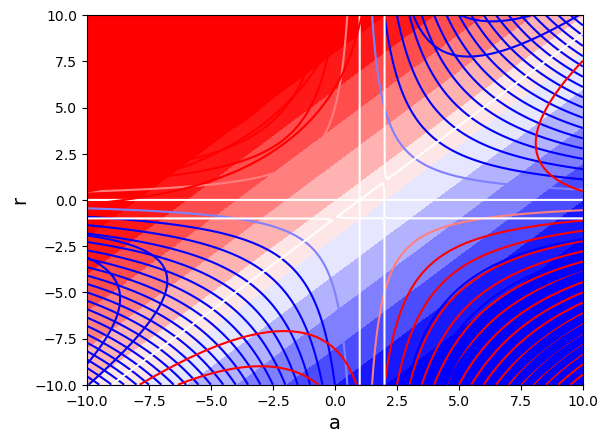

In [39]:
Map = 'bwr'

norm = mcolors.TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)

plt.contourf(A,R,inEq1,cmap=Map, norm=norm, levels=25)
plt.contour(A,R,inEq2,cmap=Map, norm=norm,levels=50)
plt.contour(A,R,inEq3,cmap=Map, norm=norm,levels=50)

plt.xlabel('a',fontsize=14)
plt.ylabel('r',fontsize=14)

plt.savefig('./HW_1b_contour.png')

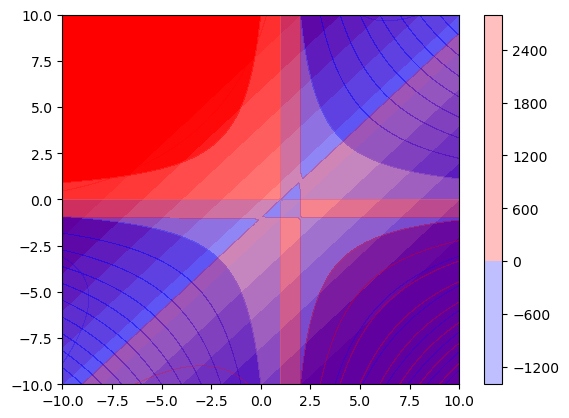

In [40]:
plt.contourf(A,R,inEq1,cmap=Map, norm=norm, levels=25)
plt.contourf(A,R,inEq2,cmap=Map,alpha=0.5, norm=norm,levels=25)
plt.contourf(A,R,inEq3,alpha=0.25,cmap=Map, norm=norm,levels=25)
plt.colorbar()

plt.show()

# 2

In [41]:
a,x = smp.symbols('a x')

f = a*x*(2-x)-x
f

a*x*(2 - x) - x

In [42]:
smp.solve(f,x)

[0, 2 - 1/a]

## C

In [43]:
a, x = smp.symbols('a x')

f = a*x*(2-x)

f

a*x*(2 - x)

In [44]:
ff = f.subs(x,f)

ff

a**2*x*(2 - x)*(-a*x*(2 - x) + 2)

In [45]:
ff.expand()

-a**3*x**4 + 4*a**3*x**3 - 4*a**3*x**2 - 2*a**2*x**2 + 4*a**2*x

In [46]:
smp.solve(ff-x,x)

[0,
 (2*a - 1)/a,
 (2*a - sqrt(4*a**2 - 4*a - 3) + 1)/(2*a),
 (2*a + sqrt(4*a**2 - 4*a - 3) + 1)/(2*a)]

In [47]:
root1 = smp.solve(ff-x,x)[0]
root2 = smp.solve(ff-x,x)[1]
root3 = smp.solve(ff-x,x)[2]
root4 = smp.solve(ff-x,x)[3]

In [48]:
root2

(2*a - 1)/a

In [49]:
root3.simplify()

(2*a - sqrt(4*a**2 - 4*a - 3) + 1)/(2*a)

In [50]:
root4

(2*a + sqrt(4*a**2 - 4*a - 3) + 1)/(2*a)